<H1>Bayesian Linear Regression Using Tensorflow Probability</H1>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp


print('TF version:', tf.__version__)
print('TFP version:', tfp.__version__)

2025-08-27 22:28:03.837156: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-27 22:28:03.872516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
TFP version: 0.25.0


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

<H1>1) Data Generation</H1>

$\large\text{Create a training set that reprents the folowing linear function: }$<br>
$$\large y_{i}=2+3.25x_{i}+\epsilon_{i}\quad\quad\quad\text{ and }\epsilon\sim\mathcal{N}\left(0,\sigma^{2}I\right)$$

In [4]:
# Create and plot training data
# Set the desired slope
desired_slope = 3.25
# Set the desired intercept
desired_intercept = 2
# Set number of samples we want in our training data set
num_training_samples = 1000
x_train = np.linspace(-2, 2, num_training_samples)[:, np.newaxis]
# Append a column of ones to x_train for the intercept term
#x_train = np.hstack((np.ones_like(x_train), x_train))

x_train shape: (1000, 1)
y_train shape: (1000, 1)


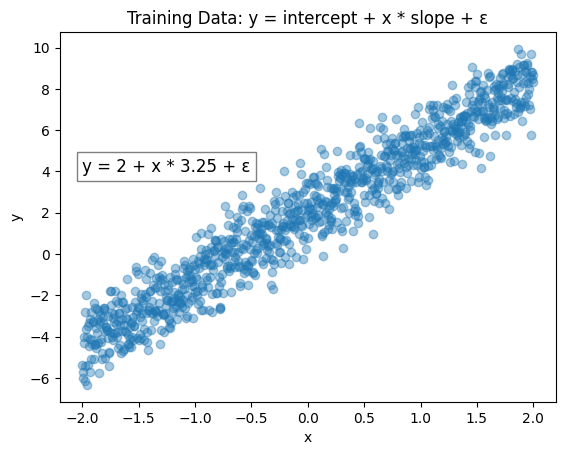

In [5]:
# Generate dependent variable y as a function of the training data x, the desired slope, and the desired intercept
#y_train = np.add(np.add(np.dot(x_train[:,1], desired_slope) ,desired_intercept), np.random.randn(num_training_samples))#[:, np.newaxis]
y_train = desired_intercept + x_train * desired_slope + np.random.randn(num_training_samples)[:, np.newaxis]
# Print the shape of x_train and y_train
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
# Plot the training data (ignoring the intercept term in each entry of x_train)
#plt.scatter(x_train[:,1], y_train, alpha=0.4)
plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data: y = intercept + x * slope + \u03B5')
plt.xlabel('x')
plt.ylabel('y')
plt.text(-2., 4, f'y = {desired_intercept} + x * {desired_slope} + \u03B5',
                       fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')) 
plt.show()


<H1>2) Consider the frequentist linear regression model</H1>

Let $n$ be the number of training samples and $m$ be the number of features in the training data.

$$\large\underset{\left(nx1\right)}{Y}=\begin{pmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{n-1} \end{pmatrix}, 

\quad\underset{\left(nxm\right)}{X}=\left[\begin{matrix}
x_{0,0}=1 & x_{0,11} &\dots &x_{0,m-1} \\
x_{1,0}=1 & x_{1,1} &\dots &x_{1,m-1} \\
\vdots & \dots & \ddots & \vdots\\
x_{n-1,0}=1 & \dots & \dots &x_{N-1, m-1}
\end{matrix}\right]$$


$$\large\mathbb{E}\left[Y\right]=X\hat{\beta}$$
$$\large\hat{\beta}\sim\mathcal{N}(\hat{\beta} X, \hat{\sigma}^{2}I)$$


$$\large\beta=\begin{pmatrix}
\beta_{0} \\
\beta_{1} \\
\vdots \\
\beta_{m} \end{pmatrix} \large\quad\text{and }\beta_{i}\sim\mathcal{N}\left(\mu_{i}, \sigma_{i}^{2}\right)$$


$$\large \hat{\beta}=\left(X^{T} X\right)^{-1}X^{T}y$$
$$\large V_{\beta}=\left(X^{T}X\right)^{-1}$$

$$\large\quad\underset{\left(nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}
\text{where }\epsilon_{i}\sim\mathcal{N}\left(\mu_{error}, \sigma_{error}^{2}\right)\text{ for }\forall i\in\left[0,n\right]$$

$\large\text{Computing }\left(X^{T}X\right)^{-1}\text{becomes a limiting factor in scaling the algorithm to large data sets.}$<br>


<H1>3) Configure the Bayesian regression model</H1>

$$\large P(\beta|\sigma, y)\sim\mathcal{N}\left(\hat{\beta},V_{\beta}\sigma_{\hat{\beta}}^{2}\right)$$

$$P\left(\sigma^{2}|y\right) = \frac{P\left(\beta, \sigma^{2}|y\right)}{P\left(\beta,\sigma^{2}|y\right)}$$

$$\large P\left(\sigma^{2} | y \right) \sim\text{Inv-} \chi^{2}\left(n=k, s^{s}\right)$$

$$\large s^{2}=\frac{1}{n-k}\left(y - X\hat{\beta}\right)^{T}\left(y - X\hat{\beta}\right)$$

In [6]:
# Train model using the negative loglikelihood
def nll(y_true, y_pred):
    return -y_pred.log_prob(y_true)

In [7]:
# Create probabilistic regression with normal distribution as final layer where the mean is learned
# and the sd is learned as well.
# model = tf.keras.models.Sequential([Dense(units=2, input_shape=(1,)),
#    tfp.layers.DistributionLambda(lambda t: tfp.distributions.Independent(tfp.distributions.Normal(loc=t[..., :1], scale=tf.math.softplus(t[..., 1:]))),
#        convert_to_tensor_fn=tfp.distributions.Distribution.sample)])

model = tf.keras.models.Sequential([Dense(units=2, input_shape=(1,)),
    tfp.layers.DistributionLambda(lambda t: tfp.distributions.           InverseGamma(concentration=t[..., :1], scale=tf.math.softplus(t[..., 1:])),
            convert_to_tensor_fn=tfp.distributions.Distribution.sample)])


model.compile(loss=nll, optimizer=RMSprop(learning_rate=0.005))
model.summary()
#model.fit(x_train, y_train, epochs=200, verbose=False)

I0000 00:00:1756333685.529353  149104 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 103 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:02:00.0, compute capability: 8.6
I0000 00:00:1756333685.541945  149104 cuda_executor.cc:508] failed to allocate 103.12MiB (108134400 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 4         
                                                                 
 distribution_lambda (Distr  ((None, 1),               0         
 ibutionLambda)               (None, 1))                         
                                                                 
Total params: 4 (16.00 Byte)
Trainable params: 4 (16.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
# Train model, record weights after each epoch
epochs = [0]
training_weights = [model.weights[0].numpy()[0, 0]]
training_bias = [model.weights[1].numpy()[0]]
for epoch in range(100):
    model.fit(x=x_train, y=y_train, epochs=1, verbose=False)
    #model.fit(x=x_train, y=y_train, epochs=1, verbose=False)
    epochs.append(epoch)
    training_weights.append(model.weights[0].numpy()[0, 0])
    training_bias.append(model.weights[1].numpy()[0])

E0000 00:00:1756333686.189914  149225 cuda_blas.cc:196] failed to create cublas handle: the resource allocation failed
E0000 00:00:1756333686.189942  149225 cuda_blas.cc:199] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with support for the GPU in your machine.
2025-08-27 22:28:06.189964: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INTERNAL: No blas support for stream
	 [[{{node sequential/dense/MatMul}}]]


InternalError: Graph execution error:

Detected at node sequential/dense/MatMul defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/ipykernel_launcher.py", line 18, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 739, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 545, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-packages/ipyke

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_78594/1661637805.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_train, y_hat, color='red', alpha=0.8, label='model $\mu$')
/tmp/ipykernel_78594/1661637805.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(x_train, y_hat_m2sd, color='green', alpha=0.8, label='model $\mu \pm 2 \sigma$')


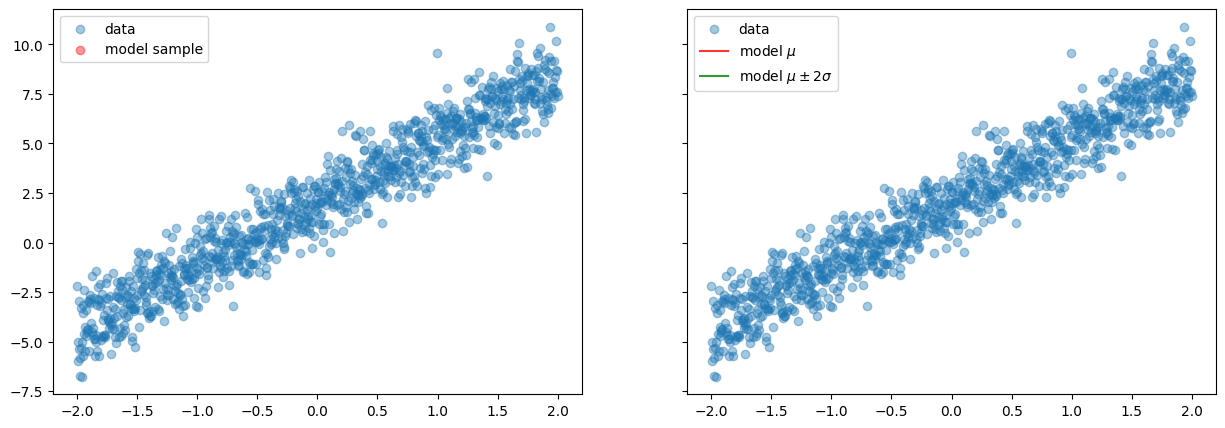

In [ ]:
# Plot the data and a sample from the model

y_model = model(x_train)
y_sample = y_model.sample()
y_hat = y_model.mean()
y_sd = y_model.stddev()
y_hat_m2sd = y_hat - 2 * y_sd
y_hat_p2sd = y_hat + 2 * y_sd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
ax1.scatter(x_train, y_train, alpha=0.4, label='data')
ax1.scatter(x_train, y_sample, alpha=0.4, color='red', label='model sample')
ax1.legend()
ax2.scatter(x_train, y_train, alpha=0.4, label='data')
ax2.plot(x_train, y_hat, color='red', alpha=0.8, label='model $\mu$')
ax2.plot(x_train, y_hat_m2sd, color='green', alpha=0.8, label='model $\mu \pm 2 \sigma$')
ax2.plot(x_train, y_hat_p2sd, color='green', alpha=0.8)
ax2.legend()
plt.show()

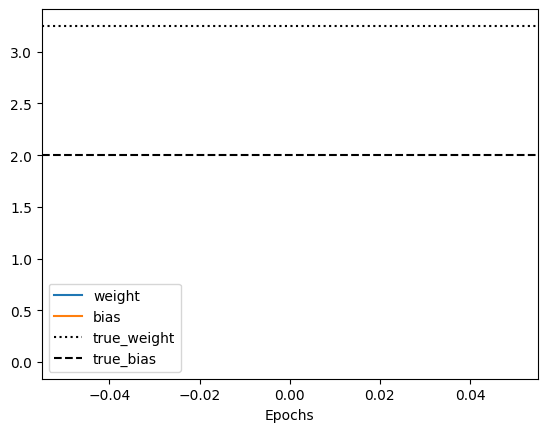

In [ ]:
# Plot the model weights as they train, converging to the correct values
plt.plot(epochs, training_weights, label='weight')
plt.plot(epochs, training_bias, label='bias')
plt.axhline(y=3.25, label='true_weight', color='k', linestyle=':')
plt.axhline(y=2, label='true_bias', color='k', linestyle='--')
plt.xlabel('Epochs')
plt.legend()
plt.show()

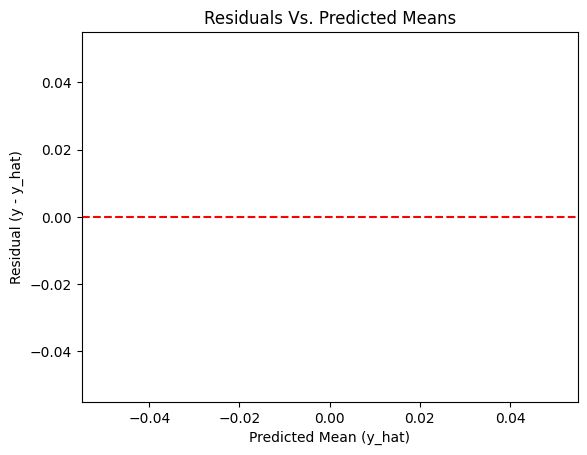

In [ ]:
# Plot the residuals
residuals = y_train - y_hat
plt.scatter(x_train, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs. Predicted Means')
plt.xlabel(r'Predicted Mean (y_hat)')
plt.ylabel('Residual (y - y_hat)')
plt.show()

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

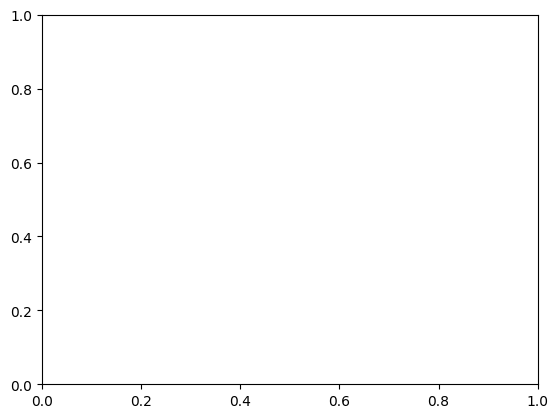

In [ ]:
# Plot historgram of residuals
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='green')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (y - y_hat)')
plt.ylabel('Density')
plt.show() 

<H1>4) Make predictions on new data</H1>

$$\begin{align*}
\large P\left(Y|X,\hat{\beta}, \hat{\sigma}^{2}\right)& \propto\frac{P\left(X,\hat{\beta}, \hat{\sigma}^{2}|Y\right)P\left(X,\hat{\beta}, \hat{\sigma}^{2}\right)}{P\left(Y\right)} \\
& =\frac{P\left(X|Y,\hat{\beta}, \hat{\sigma}^{2}\right)P\left(X\right)}{P\left(Y\right)}\quad\text{since }\hat{\beta}\text{ and }\hat{\sigma^{2}}\text{ are constant in the likelihood.}
\end{align*}$$

<H1>References</H1>

1. Gelman A., Carlin J., Stern H., Dunson D., Vehtari A., Rubin D., "Bayesian Data Analysis", CRC Press, Boca Raton FL, 3rd ed., 2014.